# 02 - Entrenamiento y evaluacion


Ejecuta primero los notebooks 00 y 01. Este notebook espera `data/dataset.yaml` y los splits procesados. Los comprimidos detectados en `Images/` deben haberse extraido previamente y el notebook 01 debe haber generado exactamente 700/150/150 imagenes en train/val/test.


## Modelo elegido: YOLOv8s

YOLOv8s equilibra capacidad y riesgo de sobreajuste para 1.700 imagenes. Se usan pesos COCO (`yolov8s.pt`) para transfer learning.


## 1. Configuracion del entrenamiento


In [1]:
from pathlib import Path
import shutil
import time

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
from ultralytics import YOLO

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

CONFIG = {
    "model":        "yolov8s.pt",
    "data":         str(PROJECT_ROOT / "data" / "dataset.yaml"),
    "epochs":       100,
    "patience":     20,
    "batch":        16,
    "imgsz":        640,
    "optimizer":    "AdamW",
    "lr0":          0.001,
    "lrf":          0.01,
    "momentum":     0.937,
    "weight_decay": 0.0005,
    "warmup_epochs":3,
    "cos_lr":       True,
    "dropout":      0.0,
    "mosaic":       1.0,
    "mixup":        0.1,
    "fliplr":       0.5,
    "flipud":       0.0,
    "hsv_h":        0.015,
    "hsv_s":        0.7,
    "hsv_v":        0.4,
    "degrees":      5.0,
    "translate":    0.1,
    "scale":        0.5,
    "perspective":  0.0,
    "device":       0,
    "workers":      8,
    "seed":         42,
    "project":      str(PROJECT_ROOT / "models" / "runs"),
    "name":         "fire_smoke_v3_balanced",
    "exist_ok":     False,
    "pretrained":   True,
    "verbose":      True,
    "save":         True,
    "save_period":  10,
    "plots":        True,
}

# No se usa dropout explicito: YOLOv8 se regulariza aqui con weight decay,
# augmentacion, early stopping y transfer learning; su neck/cabeza no son una
# red clasificadora densa donde dropout sea el primer recurso.
RUN_DIR = Path(CONFIG["project"]) / CONFIG["name"]
PLOTS_DIR = RUN_DIR / "plots_custom"
CONFIG


{'model': 'yolov8s.pt',
 'data': 'C:\\Users\\luish\\Documents\\CEIABD\\Proyecto\\data\\dataset.yaml',
 'epochs': 100,
 'patience': 20,
 'batch': 16,
 'imgsz': 640,
 'optimizer': 'AdamW',
 'lr0': 0.001,
 'lrf': 0.01,
 'momentum': 0.937,
 'weight_decay': 0.0005,
 'warmup_epochs': 3,
 'cos_lr': True,
 'dropout': 0.0,
 'mosaic': 1.0,
 'mixup': 0.1,
 'fliplr': 0.5,
 'flipud': 0.0,
 'hsv_h': 0.015,
 'hsv_s': 0.7,
 'hsv_v': 0.4,
 'degrees': 5.0,
 'translate': 0.1,
 'scale': 0.5,
 'perspective': 0.0,
 'device': 0,
 'workers': 8,
 'seed': 42,
 'project': 'C:\\Users\\luish\\Documents\\CEIABD\\Proyecto\\models\\runs',
 'name': 'fire_smoke_v3_balanced',
 'exist_ok': False,
 'pretrained': True,
 'verbose': True,
 'save': True,
 'save_period': 10,
 'plots': True}

## 2. Entrenamiento


In [2]:
if RUN_DIR.exists() and not CONFIG["exist_ok"]:
    raise FileExistsError(f"Ya existe {RUN_DIR}. Cambia CONFIG['name'] o activa CONFIG['exist_ok'].")
if not Path(CONFIG["data"]).exists():
    raise FileNotFoundError("No existe data/dataset.yaml. Ejecuta antes el notebook 01.")

required_splits = {
    "train": PROJECT_ROOT / "data" / "processed" / "images" / "train",
    "val": PROJECT_ROOT / "data" / "processed" / "images" / "val",
    "test": PROJECT_ROOT / "data" / "processed" / "images" / "test",
}
for split, folder in required_splits.items():
    n_images = len([p for p in folder.glob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tiff", ".tif"}])
    if n_images == 0:
        raise FileNotFoundError(f"El split {split} esta vacio en {folder}. Ejecuta antes el notebook 01.")


In [3]:
model = YOLO(CONFIG["model"])
results = model.train(**CONFIG)
RUN_DIR = Path(CONFIG["project"]) / CONFIG["name"]
PLOTS_DIR = RUN_DIR / "plots_custom"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)


Ultralytics 8.4.53  Python-3.12.6 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)


engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=C:\Users\luish\Documents\CEIABD\Proyecto\data\dataset.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=fire_smoke_v3_balanced, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=20, perspective=0.0, plots=True, pose=12.0

Overriding model.yaml nc=80 with nc=2



                   from  n    params  module                                       arguments                     


  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 


...

                   all        255        298      0.705      0.638      0.645      0.324


                  fire        105        188      0.757      0.777      0.779       0.46


                 smoke        105        110      0.653        0.5      0.512      0.188


Speed: 0.2ms preprocess, 2.1ms inference, 0.0ms loss, 1.2ms postprocess per image


Results saved to C:\Users\luish\Documents\CEIABD\Proyecto\models\runs\fire_smoke_v3_balanced


## 3. Metricas y curvas


In [4]:
history = pd.read_csv(RUN_DIR / "results.csv")
history.columns = [c.strip() for c in history.columns]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, pair in zip(axes, [("train/box_loss", "val/box_loss"), ("train/cls_loss", "val/cls_loss"), ("train/dfl_loss", "val/dfl_loss")]):
    ax.plot(history["epoch"], history[pair[0]], label="train")
    ax.plot(history["epoch"], history[pair[1]], label="val")
    ax.set_title(pair[0].split("/")[1])
    ax.grid(True, alpha=0.3)
    ax.legend()
fig.savefig(PLOTS_DIR / "loss_curves.png", dpi=160)
plt.show()

best_epoch = int(history.loc[history["metrics/mAP50(B)"].idxmax(), "epoch"])
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), ["metrics/precision(B)", "metrics/recall(B)", "metrics/mAP50(B)", "metrics/mAP50-95(B)"]):
    ax.plot(history["epoch"], history[col])
    ax.axvline(best_epoch, color="red", linestyle="--", label=f"best mAP50 {best_epoch}")
    ax.set_title(col)
    ax.grid(True, alpha=0.3)
    ax.legend()
fig.savefig(PLOTS_DIR / "detection_metrics_curves.png", dpi=160)
plt.show()


<Figure size 1600x400 with 3 Axes>

<Figure size 1200x800 with 4 Axes>

### Evaluacion en test: PR, confusion y F1


Ultralytics 8.4.53  Python-3.12.6 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)


Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs


val: Fast image access  (ping: 0.10.0 ms, read: 61.564.7 MB/s, size: 369.4 KB)


val: Scanning C:\Users\luish\Documents\CEIABD\Proyecto\data\processed\labels\test... 63 images, 45 backgrounds, 0 corrupt: 25% ━━╸───────── 63/255 177.5it/s 0.1s<1.1s

val: Scanning C:\Users\luish\Documents\CEIABD\Proyecto\data\processed\labels\test... 77 images, 45 backgrounds, 0 corrupt: 30% ━━━╸──────── 77/255 163.1it/s 0.2s<1.1s

...

                   all        255        325      0.725      0.596       0.65        0.3


                  fire        105        215      0.618      0.609      0.623      0.311


                 smoke        105        110      0.832      0.582      0.678      0.289


Speed: 0.9ms preprocess, 4.2ms inference, 0.0ms loss, 0.9ms postprocess per image


Results saved to C:\Users\luish\Documents\CEIABD\Proyecto\models\runs\fire_smoke_v3_balanced\test_eval\val_test


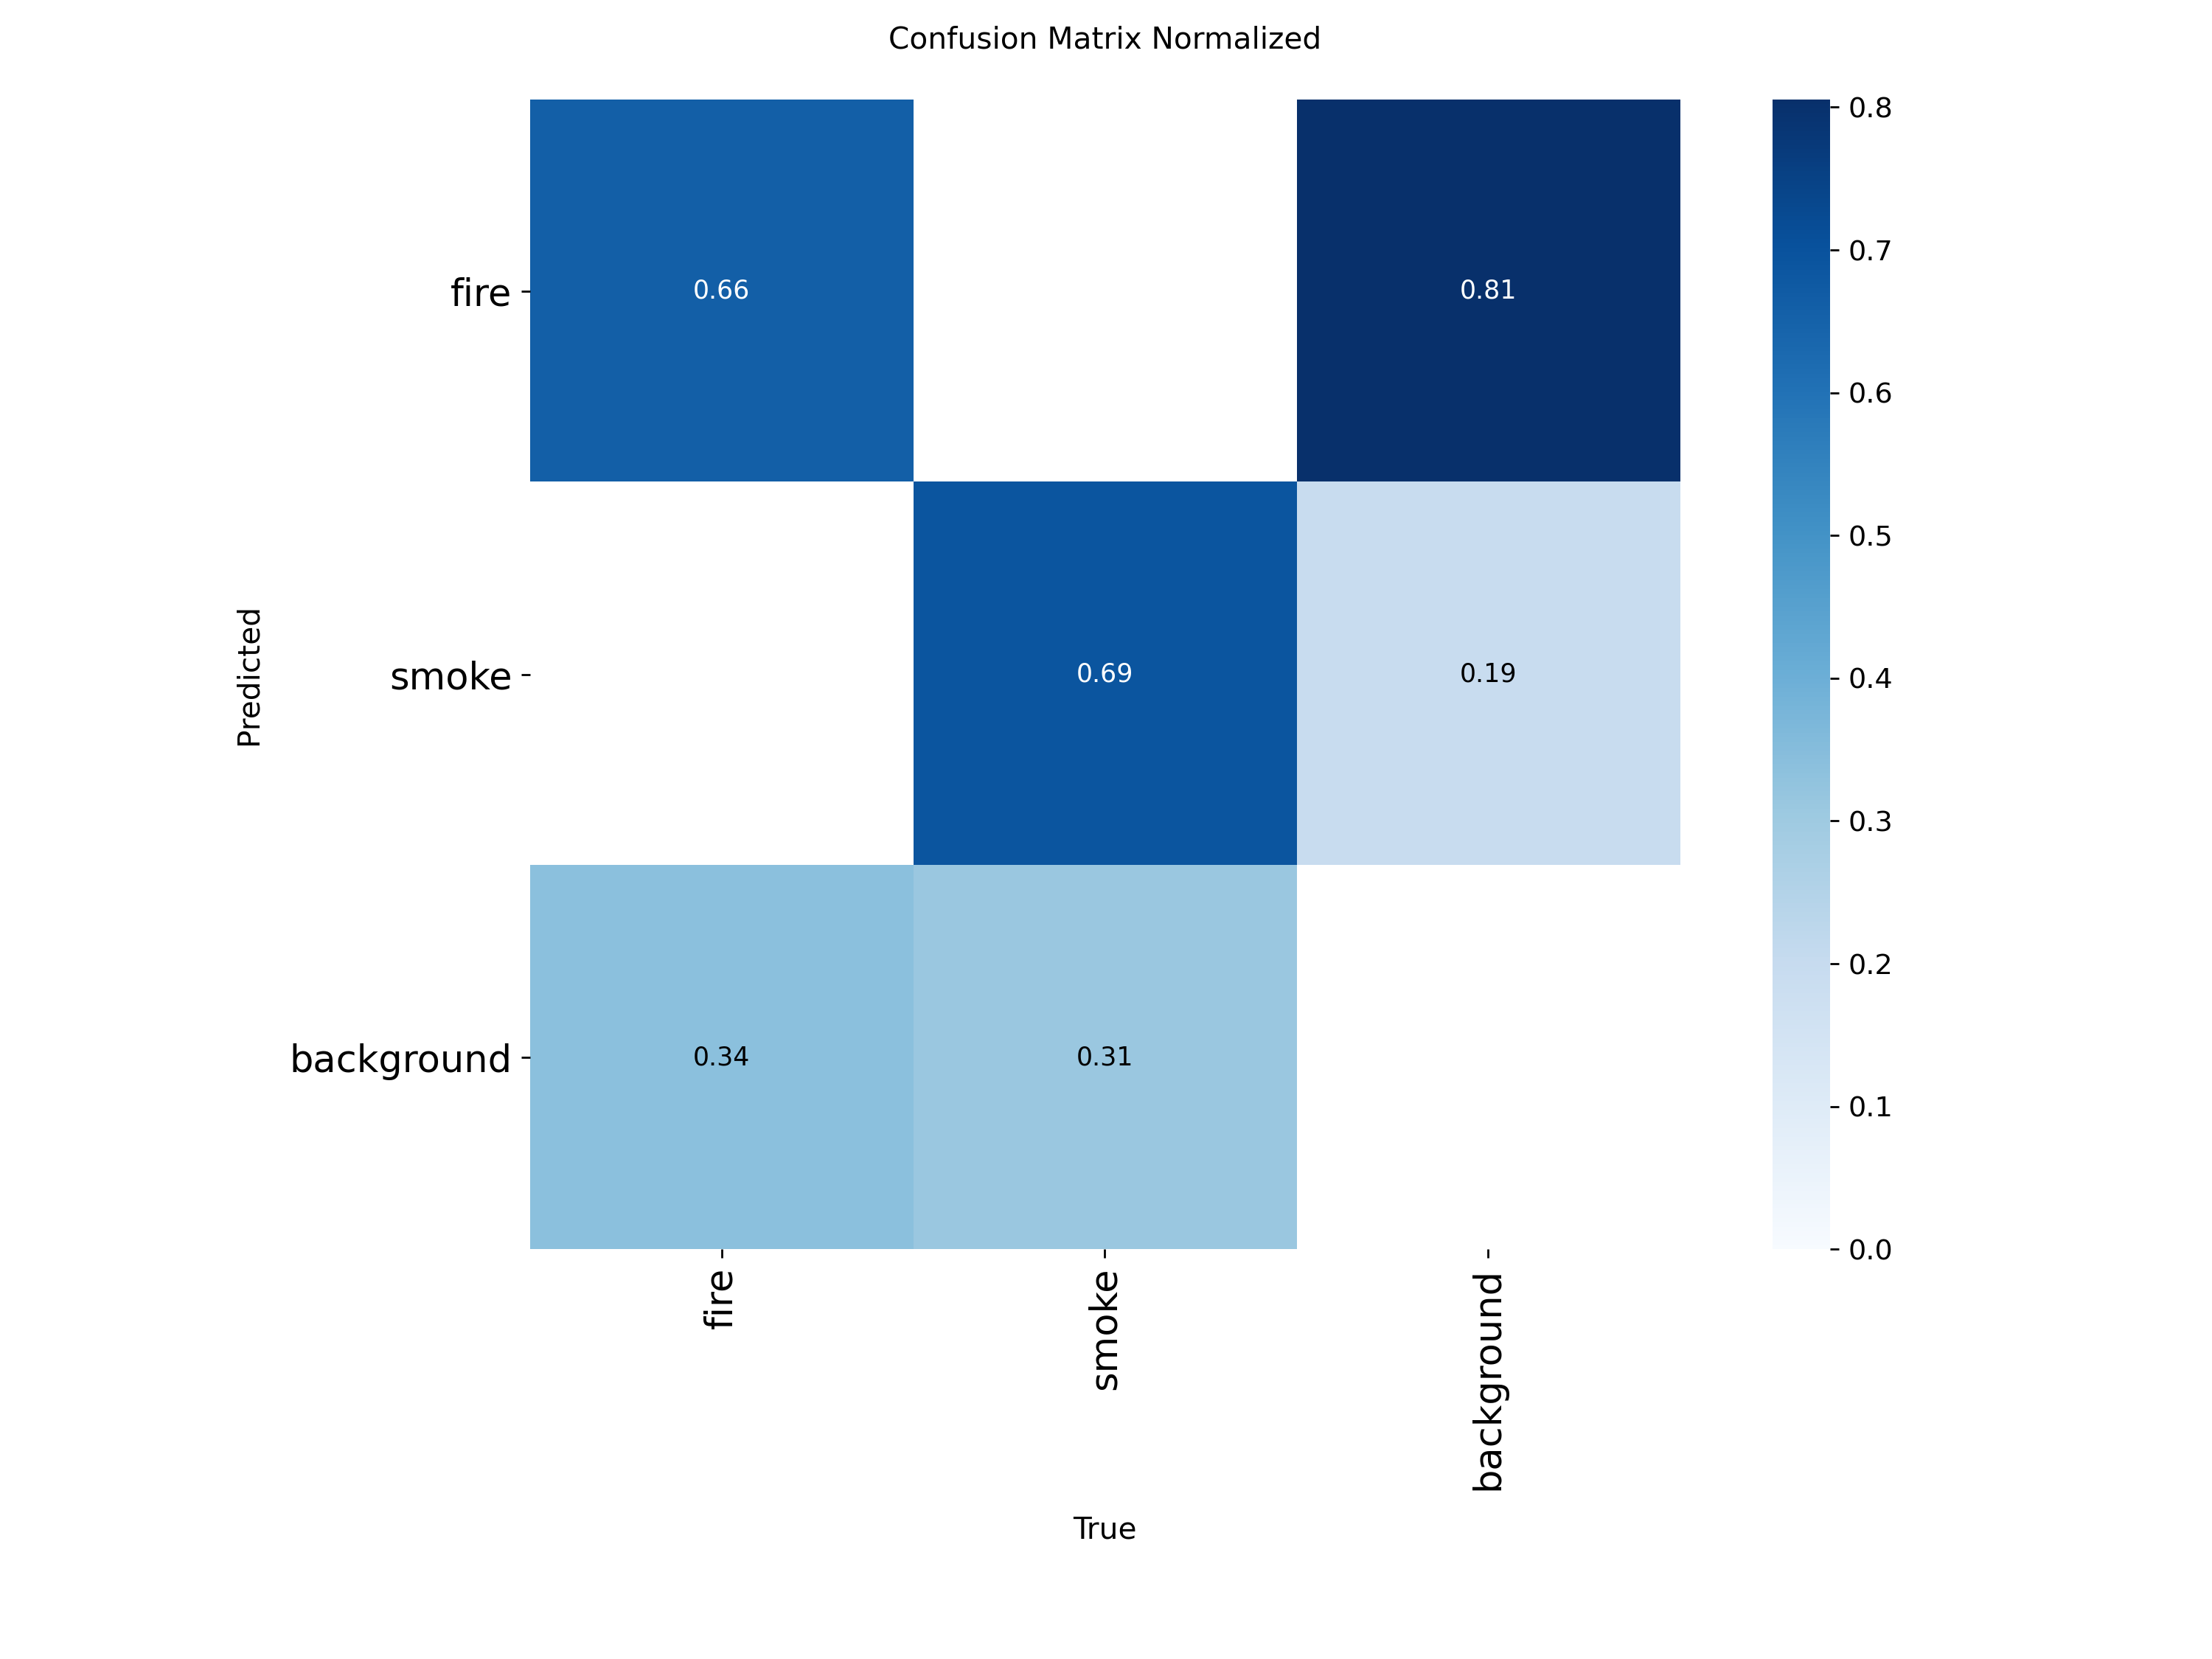

In [5]:
best_model_path = RUN_DIR / "weights" / "best.pt"
model = YOLO(str(best_model_path))
test_eval_dir = RUN_DIR / "test_eval"
test_metrics = model.val(data=CONFIG["data"], split="test", plots=True,
                         project=str(test_eval_dir), name="val_test",
                         exist_ok=True, conf=0.001)

for src_name, dst_name in [
    ("PR_curve.png", "precision_recall_curve_ultralytics.png"),
    ("confusion_matrix_normalized.png", "confusion_matrix_normalized_ultralytics.png"),
    ("F1_curve.png", "f1_confidence_curve_ultralytics.png"),
]:
    src = test_eval_dir / "val_test" / src_name
    if src.exists():
        shutil.copy2(src, PLOTS_DIR / dst_name)
        display(Image.open(src))


In [6]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tiff", ".tif"}
CLASS_NAMES = {0: "fire", 1: "smoke"}
TEST_IMAGES = [p for p in sorted((PROJECT_ROOT / "data" / "processed" / "images" / "test").glob("*")) if p.suffix.lower() in IMAGE_EXTS]
TEST_LABEL_DIR = PROJECT_ROOT / "data" / "processed" / "labels" / "test"

def load_yolo_label(path: Path):
    label = TEST_LABEL_DIR / f"{path.stem}.txt"
    boxes = []
    if not label.exists():
        return boxes
    with Image.open(path) as img:
        iw, ih = img.size
    for line in label.read_text(encoding="utf-8").splitlines():
        parts = line.split()
        if len(parts) >= 5:
            cls = int(float(parts[0])); x, y, w, h = map(float, parts[1:5])
            boxes.append((cls, (x - w / 2) * iw, (y - h / 2) * ih, (x + w / 2) * iw, (y + h / 2) * ih))
    return boxes

def iou(a, b):
    ax1, ay1, ax2, ay2 = a; bx1, by1, bx2, by2 = b
    ix1, iy1, ix2, iy2 = max(ax1, bx1), max(ay1, by1), min(ax2, bx2), min(ay2, by2)
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    area_a = max(0, ax2 - ax1) * max(0, ay2 - ay1)
    area_b = max(0, bx2 - bx1) * max(0, by2 - by1)
    return inter / max(area_a + area_b - inter, 1e-9)

predictions = []
start = time.perf_counter()
for image_path in TEST_IMAGES:
    result = model.predict(str(image_path), conf=0.001, iou=0.45, imgsz=CONFIG["imgsz"], device=CONFIG["device"], verbose=False)[0]
    pred = []
    if result.boxes is not None:
        for cls, box, conf in zip(result.boxes.cls.cpu().numpy().astype(int), result.boxes.xyxy.cpu().numpy(), result.boxes.conf.cpu().numpy()):
            pred.append((int(cls), float(box[0]), float(box[1]), float(box[2]), float(box[3]), float(conf)))
    predictions.append({"image": image_path, "gt": load_yolo_label(image_path), "pred": pred})
infer_ms = (time.perf_counter() - start) / max(len(TEST_IMAGES), 1) * 1000

def evaluate_threshold(threshold, iou_thr=0.5):
    rows = []
    for cls in [0, 1]:
        tp = fp = fn = 0
        for item in predictions:
            gt = [b[1:] for b in item["gt"] if b[0] == cls]
            preds = [p for p in item["pred"] if p[0] == cls and p[5] >= threshold]
            matched = set()
            for _, x1, y1, x2, y2, conf in sorted(preds, key=lambda x: x[5], reverse=True):
                scores = [(idx, iou((x1, y1, x2, y2), g)) for idx, g in enumerate(gt) if idx not in matched]
                best = max(scores, key=lambda x: x[1], default=(None, 0))
                if best[1] >= iou_thr:
                    tp += 1; matched.add(best[0])
                else:
                    fp += 1
            fn += len(gt) - len(matched)
        precision = tp / max(tp + fp, 1)
        recall = tp / max(tp + fn, 1)
        f1 = 2 * precision * recall / max(precision + recall, 1e-9)
        rows.append({"class": CLASS_NAMES[cls], "threshold": threshold, "precision": precision, "recall": recall, "f1": f1})
    return rows

thresholds = np.linspace(0.05, 0.95, 19)
curve_df = pd.DataFrame([r for thr in thresholds for r in evaluate_threshold(float(thr))])

fig, ax = plt.subplots(figsize=(7, 5))
for cls_name, group in curve_df.groupby("class"):
    ordered = group.sort_values("recall")
    ap = np.trapezoid(ordered["precision"], ordered["recall"])
    ax.plot(group["recall"], group["precision"], marker="o", label=f"{cls_name} AP~{ap:.3f}")
mean_curve = curve_df.groupby("threshold")[["precision", "recall"]].mean().reset_index()
ax.plot(mean_curve["recall"], mean_curve["precision"], color="black", linewidth=2, label="media")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision"); ax.grid(True, alpha=0.3); ax.legend()
fig.savefig(PLOTS_DIR / "precision_recall_curve_custom.png", dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
for cls_name, group in curve_df.groupby("class"):
    best = group.loc[group["f1"].idxmax()]
    ax.plot(group["threshold"], group["f1"], marker="o", label=f"{cls_name} best {best['threshold']:.2f}")
    ax.axvline(best["threshold"], linestyle="--", alpha=0.4)
ax.set_xlabel("Confianza"); ax.set_ylabel("F1"); ax.grid(True, alpha=0.3); ax.legend()
fig.savefig(PLOTS_DIR / "f1_confidence_curve_custom.png", dpi=160)
plt.show()

try:
    cm = test_metrics.confusion_matrix.matrix
    cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    labels = ["fire", "smoke", "background"][:cm_norm.shape[0]]
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=labels, yticklabels=labels, ax=ax)
    fig.savefig(PLOTS_DIR / "confusion_matrix_normalized_custom.png", dpi=160)
    plt.show()
except Exception as exc:
    print(f"[WARN] No se pudo reconstruir matriz con seaborn: {exc}")


<Figure size 700x500 with 1 Axes>

<Figure size 700x500 with 1 Axes>

<Figure size 600x500 with 2 Axes>

### 3.6 Ejemplos visuales de prediccion


In [7]:
def is_success(item, thr=0.25):
    for cls in [0, 1]:
        gt = [b[1:] for b in item["gt"] if b[0] == cls]
        preds = [p for p in item["pred"] if p[0] == cls and p[5] >= thr]
        if gt and not preds:
            return False
        if not gt and preds:
            return False
        for gt_box in gt:
            if not any(iou(gt_box, p[1:5]) >= 0.5 for p in preds):
                return False
    return True

successes = [p for p in predictions if is_success(p)]
errors = [p for p in predictions if not is_success(p)]
examples = (successes[:8] + errors[:8] + predictions)[:16]

fig, axes = plt.subplots(4, 4, figsize=(16, 14))
for ax, item in zip(axes.ravel(), examples):
    img = cv2.cvtColor(cv2.imread(str(item["image"])), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    for cls, x1, y1, x2, y2, conf in item["pred"]:
        if conf < 0.25:
            continue
        color = "orangered" if cls == 0 else "gray"
        ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color=color, linewidth=2))
        ax.text(x1, max(0, y1 - 3), f"{CLASS_NAMES[cls]} {conf:.2f}", color="white", fontsize=8,
                bbox=dict(facecolor=color, alpha=0.8))
    ax.set_title(("OK" if is_success(item) else "ERROR") + " - " + item["image"].name[:24], fontsize=8)
    ax.axis("off")
for ax in axes.ravel()[len(examples):]:
    ax.axis("off")
fig.savefig(PLOTS_DIR / "prediction_examples_4x4.png", dpi=160)
plt.show()


<Figure size 1600x1400 with 16 Axes>

## 4. Evaluacion cuantitativa final


In [8]:
box = test_metrics.box
summary_table = pd.DataFrame({
    "Metrica": ["Precision", "Recall", "mAP@0.5", "mAP@0.5:0.95"],
    "fire": [box.p[0] if len(box.p) > 0 else np.nan, box.r[0] if len(box.r) > 0 else np.nan,
             box.ap50[0] if len(box.ap50) > 0 else np.nan, box.ap[0] if len(box.ap) > 0 else np.nan],
    "smoke": [box.p[1] if len(box.p) > 1 else np.nan, box.r[1] if len(box.r) > 1 else np.nan,
              box.ap50[1] if len(box.ap50) > 1 else np.nan, box.ap[1] if len(box.ap) > 1 else np.nan],
    "media": [box.mp, box.mr, box.map50, box.map],
})
best_f1 = curve_df.loc[curve_df.groupby("class")["f1"].idxmax()]
f1_row = {"Metrica": "F1 (umbral optimo)",
          "fire": float(best_f1.loc[best_f1["class"] == "fire", "f1"].iloc[0]) if "fire" in set(best_f1["class"]) else np.nan,
          "smoke": float(best_f1.loc[best_f1["class"] == "smoke", "f1"].iloc[0]) if "smoke" in set(best_f1["class"]) else np.nan,
          "media": float(best_f1["f1"].mean())}
display(pd.concat([summary_table, pd.DataFrame([f1_row])], ignore_index=True))
print(f"Tiempo medio de inferencia en test: {infer_ms:.1f} ms/imagen")


,Metrica,fire,smoke,media
0,Precision,0.618359,0.832212,0.725285
1,Recall,0.609302,0.581818,0.595560
2,mAP@0.5,0.622890,0.678046,0.650468
3,mAP@0.5:0.95,0.311165,0.289279,0.300222
4,F1 (umbral optimo),0.648379,0.717489,0.682934


Tiempo medio de inferencia en test: 15.9 ms/imagen


## EXPORTACION - Ejecuta esta celda solo cuando los resultados sean satisfactorios


In [9]:
# -- EXPORTACION DEL MODELO --------------------------------------------------
# Esta celda queda protegida para ejecuciones completas del notebook.
# Cambia RUN_EXPORT a True solo cuando quieras exportar tras revisar metricas.
RUN_EXPORT = False

if not RUN_EXPORT:
    print("Exportacion omitida. Cambia RUN_EXPORT=True cuando los resultados sean satisfactorios.")
else:
    import shutil
    from pathlib import Path
    from ultralytics import YOLO

    best_run_path = Path("../models/runs/fire_smoke_v3_balanced/weights/best.pt")
    export_dir = Path("../exports")
    export_dir.mkdir(parents=True, exist_ok=True)

    shutil.copy(best_run_path, export_dir / "best_fire_smoke.pt")
    print(f"[OK] Modelo PyTorch copiado en {export_dir / 'best_fire_smoke.pt'}")

    model = YOLO(str(best_run_path))
    model.export(format="onnx", imgsz=640, dynamic=False, simplify=True, opset=17, half=False)
    onnx_src = best_run_path.with_suffix(".onnx")
    shutil.move(str(onnx_src), str(export_dir / "best_fire_smoke.onnx"))
    print(f"[OK] Modelo ONNX exportado en {export_dir / 'best_fire_smoke.onnx'}")

    # TensorRT opcional, requiere tensorrt>=8.6:
    # model.export(format="engine", imgsz=640, half=True, device=0)

    for f in sorted(export_dir.iterdir()):
        print(f"  {f.name:40s}  {f.stat().st_size / (1024**2):.1f} MB")


Exportacion omitida. Cambia RUN_EXPORT=True cuando los resultados sean satisfactorios.
